In [5]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures   

from sklearn.datasets import load_diabetes

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [9]:
model = PolynomialFeatures(degree=3, include_bias=False)

model.fit_transform([[2, 3], [4, 5]])


array([[  2.,   3.,   4.,   6.,   9.,   8.,  12.,  18.,  27.],
       [  4.,   5.,  16.,  20.,  25.,  64.,  80., 100., 125.]])

In [12]:
np.random.seed(42)
x = np.linspace(-3, 3, 200)
y = 1.5* x - 0.8 * x **x +2 + np.random.normal(0, 1.2, size=200)
X = x.reshape(-1, 1)
print(x)

[-3.         -2.96984925 -2.93969849 -2.90954774 -2.87939698 -2.84924623
 -2.81909548 -2.78894472 -2.75879397 -2.72864322 -2.69849246 -2.66834171
 -2.63819095 -2.6080402  -2.57788945 -2.54773869 -2.51758794 -2.48743719
 -2.45728643 -2.42713568 -2.39698492 -2.36683417 -2.33668342 -2.30653266
 -2.27638191 -2.24623116 -2.2160804  -2.18592965 -2.15577889 -2.12562814
 -2.09547739 -2.06532663 -2.03517588 -2.00502513 -1.97487437 -1.94472362
 -1.91457286 -1.88442211 -1.85427136 -1.8241206  -1.79396985 -1.7638191
 -1.73366834 -1.70351759 -1.67336683 -1.64321608 -1.61306533 -1.58291457
 -1.55276382 -1.52261307 -1.49246231 -1.46231156 -1.4321608  -1.40201005
 -1.3718593  -1.34170854 -1.31155779 -1.28140704 -1.25125628 -1.22110553
 -1.19095477 -1.16080402 -1.13065327 -1.10050251 -1.07035176 -1.04020101
 -1.01005025 -0.9798995  -0.94974874 -0.91959799 -0.88944724 -0.85929648
 -0.82914573 -0.79899497 -0.76884422 -0.73869347 -0.70854271 -0.67839196
 -0.64824121 -0.61809045 -0.5879397  -0.55778894 -0.

C:\Users\Анютка\AppData\Local\Temp\ipykernel_20036\3339731115.py:3: RuntimeWarning: invalid value encountered in power
  y = 1.5* x - 0.8 * x **x +2 + np.random.normal(0, 1.2, size=200)


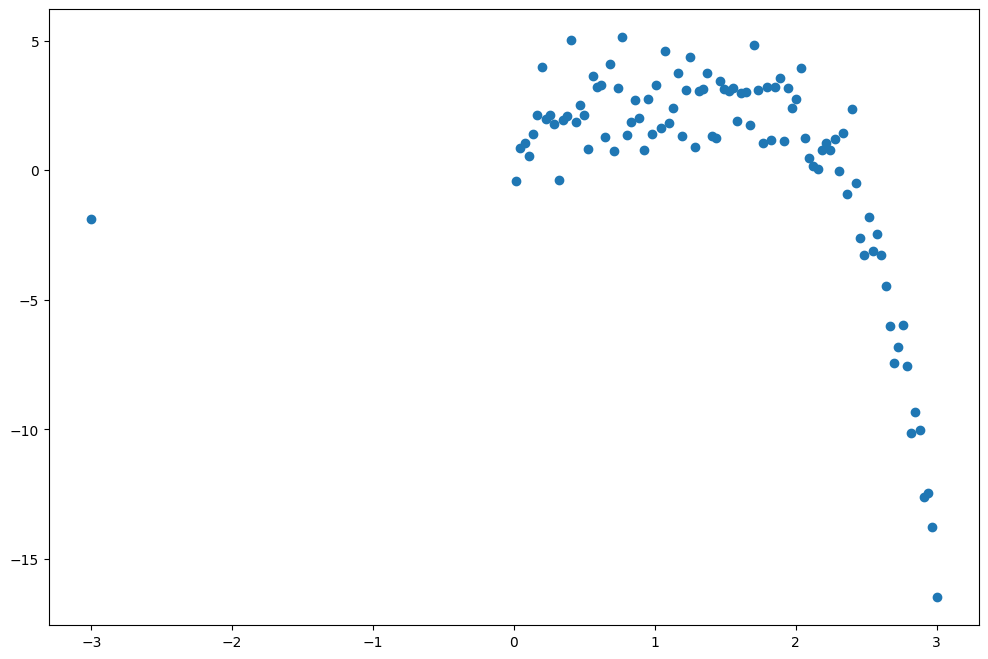

In [13]:
plt.figure(figsize=(12, 8))

plt.scatter(x, y)

plt.show()

In [25]:
from sklearn.model_selection import train_test_split

X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

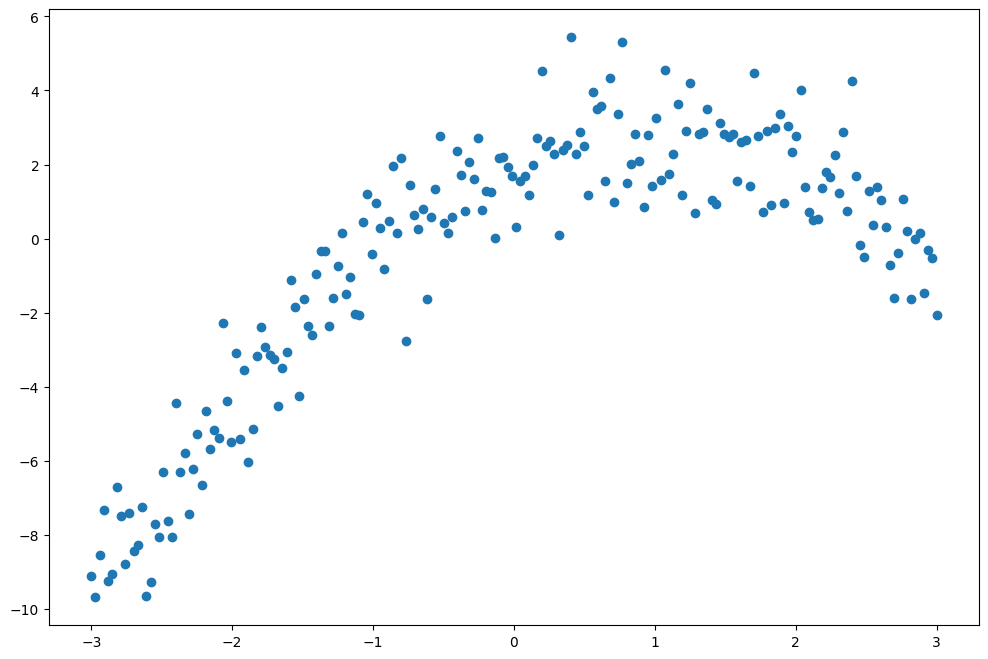

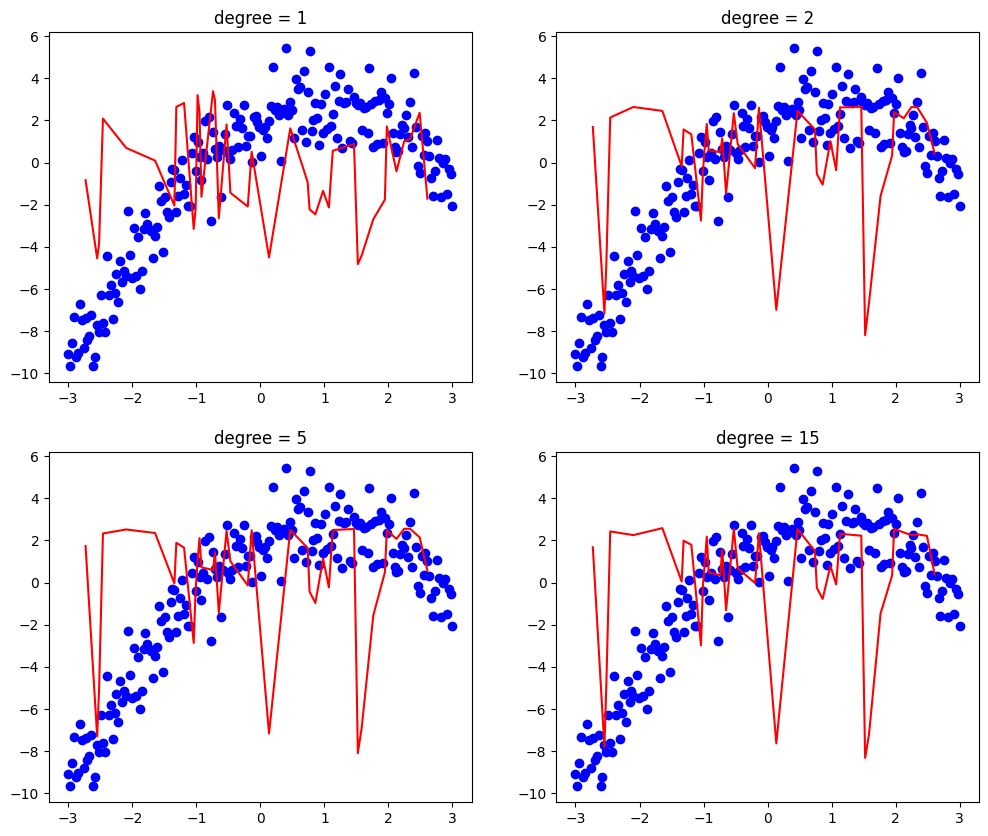

,degree,r2_train,r2_test
0,1,0.548510,0.492246
1,2,0.907735,0.897404
2,5,0.911491,0.900050
3,15,0.914993,0.894905


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
model = PolynomialFeatures(degree=3, include_bias=False)

model.fit_transform([[2, 3], [4, 5]])
# Створення поліноміальних ознак


np.random.seed(42)
x = np.linspace(-3, 3, 200)
y = 1.5 * x - 0.8 * x ** 2 + 2 + np.random.normal(0, 1.2, size=200)
X = x.reshape(-1, 1)
plt.figure(figsize=(12, 8))

plt.scatter(x, y)

plt.show()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

metrics = []

plt.figure(figsize=(12, 10))

n = 0
for d in [1, 2, 5, 15]:
    n += 1
    plt.subplot(2, 2, n)
    
    model = Pipeline(steps=[
        ("poly", PolynomialFeatures(d, include_bias=False)),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression())
    ])
    
    model.fit(X_train, y_train)
    
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    plt.scatter(x, y, color='blue')
    indx_sort = np.argsort(X_test[:, 0])
    plt.plot(X_test[indx_sort], y_pred_test, color='red')
    plt.title("degree = " + str(d))
    
    metrics.append({
        "degree": d,
        "r2_train": r2_score(y_train, y_pred_train),
        "r2_test": r2_score(y_test, y_pred_test)
    })
    
plt.show()

pd.DataFrame(metrics)

In [32]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.datasets import make_regression